ARMA Model:
The name ARMA is short for Autoregressive Moving Average. It comes from merging two simpler models - the Autoregressive, or AR, and the Moving Average, or MA. In analysis, we tend to put the residuals at the end of the model equation, so that’s why the “MA” part comes second. Of course, this will become apparent once we examine the equation.
Let’s suppose that “Y” is some random time-series variable. Then, a simple Autoregressive Moving Average model would look something like this:

yt = c + ϕ1 yt-1 + θ1 ϵ t-1 + ϵ t

If you’ve checked our previous articles on the AR and MA models, you’ve already seen ALL parts of this equation, so we’ll quickly go over all of them.

What do yt and yt-1 stand for?

For starters, yt and yt-1 represent the values in the current period and 1 period ago respectively. As was the case with the AR model, we’re using the past values as a benchmark for future estimates.

What do ϵ t and ϵ t-1 stand for?

Similarly, ϵ t and ϵ t-1 are the error terms for the same two periods. The error term from the last period is used to help us correct our predictions. By knowing how far off we were in our last estimate, we can make a more accurate estimation this time.

What does c stand for?

As always, “c” is just a baseline constant factor. In simply means we can plug in any constant factor here. If the equation doesn’t have such a baseline, we just assume c=0.

What do ϕ1 and θ1 stand for?

The two remaining parameters are ϕ1 and θ1. The former, ϕ1, expresses on average what part of the value last period (yt-1) is relevant in explaining the current one. Similarly, the latter, θ1, represents the same for the past error term (ϵ t-1). Just like in previous models, these coefficients must range between -1 and 1 to prevent the coefficients from blowing up.

Of course, in more complex models, ϕi, and θiexpress the importance of the values and error terms for the “i-th” lag. For example, ϕ4, expresses what part of the value 4 periods ago is still relevant, while θ3describes what portion of the residual from 3 periods ago is important today.


An ARMA (Autoregressive Moving Average) model is used for forecasting time series data by combining two components: the autoregressive (AR) component, which uses past values of the series, and the moving average (MA) component, which uses past forecast errors. It is suitable for forecasting stationary time series (those with constant statistical properties).

The model is denoted as ARMA(p, q), where 'p' is the order of the autoregressive part and 'q' is the order of the moving average part.

Example: 1
 Examples include forecasting personal consumption expenditure using personal income as a predictor, where the residual errors from this relationship follow an ARMA process.

Mathematical Representation of ARMA Model
The ARMA model is a combination of both AR and MA components. An ARMA(p, q) model, where
p
p is the number of lagged observations (AR part) and
q
q is the number of lagged forecast errors (MA part), is represented as:

T
t
=
c
+
Σ
i
=
1
p
ϕ
i
T
t
−
i
+
Σ
j
=
1
q
θ
j
e
t
−
j
+
e
t
T
t
​
 =c+Σ
i=1
p
​
 ϕ
i
​
 T
t−i
​
 +Σ
j=1
q
​
 θ
j
​
 e
t−j
​
 +e
t
​


How to Determine the Orders p and q in ARMA Model?
Determining the appropriate values for p and q is crucial for building an effective ARMA model. This can be done using the following methods:

Partial Autocorrelation Function (PACF):
PACF is used to determine the order p of the AR model. It measures the correlation between observations at different lags, excluding the influence of intermediate lags.

The order p is determined by the lag at which the PACF plot cuts off.

Autocorrelation Function (ACF):
ACF is used to determine the order q of the MA model. It measures the correlation between observations at different lags.
The order q is determined by the lag at which the ACF plot cuts off.



Application and Use Cases of ARMA Model
For predicting and evaluating time series data the ARMA model is extensively utilized in many different domains. A few typical uses are as follows:

Economics: Predicting stock prices, exchange rates, and economic indicators.

Weather Forecasting: Analyzing temperature, rainfall, and other meteorological data.

Sales Forecasting: Predicting future sales based on past sales data.

Engineering: Monitoring and controlling industrial processes.

Inventory management: Forecasting future demand for products.
Epidemiology: Predicting the spread of diseases.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

%matplotlib inline

In [12]:
# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
airline_data = pd.read_csv(url, index_col='Month', parse_dates=True)



In [11]:
airline_data.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [22]:
airline_data.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


Inferences:
| Statistic                        | Meaning                                | Interpretation                                                                             |
| -------------------------------- | -------------------------------------- | ------------------------------------------------------------------------------------------ |
| **Count = 144**                  | Number of monthly observations         | 12 years × 12 months = 144 months (complete data).                                         |
| **Mean = 280.30**                | Average number of passengers per month | On average, there were about **280 passengers (in thousands)** per month.                  |
| **Standard Deviation = 119.97**  | Spread or variability in the data      | Passenger numbers vary widely month to month, indicating strong **seasonal fluctuations**. |
| **Minimum = 104**                | Lowest monthly passenger count         | The lowest traffic was 104,000 passengers (likely early years such as 1949 winter months). |
| **25th Percentile (Q1) = 180**   | 25% of months had ≤ 180 passengers     | Represents lower seasonal months and early years of the dataset.                           |
| **Median (Q2) = 265.5**          | Middle value of the dataset            | Half the months had fewer than 265,000 passengers, half had more.                          |
| **75th Percentile (Q3) = 360.5** | 25% of months had ≥ 360 passengers     | These correspond to peak months in later years.                                            |
| **Maximum = 622**                | Highest monthly passenger count        | The busiest                                                                                |


Business Interpretation:

Steady Growth Over Time:

Passenger numbers increased significantly from a minimum of 104,000 to a maximum of 622,000 between 1949 and 1960, indicating a substantial rise in airline travel demand.

High Seasonality:

A large standard deviation (approximately 120,000) and a wide range (518,000) suggest strong seasonal fluctuations. Certain months—likely during summer or vacation periods—consistently experienced much higher travel volumes.
Expanding Air Travel Industry:
The upward shift in quartiles (from Q1 = 180,000 to Q3 = 360,500) shows that even the “low” months in later years surpassed the “high” months of earlier years. This reflects structural growth in the industry.

Business Implications

Airlines likely had to expand capacity and adjust schedules to accommodate seasonal demand.
Infrastructure planning—such as airport facilities and crew scheduling—needed to account for peak travel periods.
The overall growth trend highlights the increasing accessibility and popularity of air travel, signaling a positive market trajectory.


Forecasting Implications

Any forecasting model should incorporate:

A trend component to capture steady growth.
A seasonal component to reflect periodic peaks.
Possibly multiplicative seasonality, as the variance appears to increase over time.

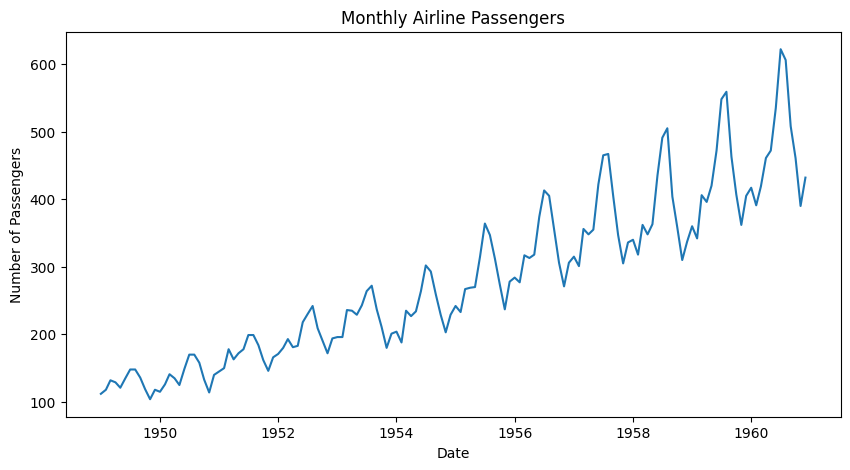

In [14]:
# Plot the dataset
plt.figure(figsize=(10, 5))
plt.plot(airline_data)
plt.title('Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.show()

Statistical Interpretation

Upward Trend:

The number of airline passengers shows a steady and continuous increase from around 1949 to 1960, indicating a significant growth in air travel demand over the years.

Strong Seasonality:

The data exhibits regular, repeating peaks and troughs each year, reflecting a clear seasonal pattern—likely influenced by holidays and travel seasons.

Increasing Amplitude:

Both the height of the peaks and the depth of the troughs increase over time, suggesting that seasonal fluctuations are becoming more pronounced. This implies that as the overall number of passengers grows, the seasonal effects intensify.

Non-Stationary Series:

Since both the mean and variance increase over time, the data is non-stationary. This means that transformations—such as logarithmic scaling or differencing—are necessary before applying certain forecasting models like ARIMA.

Business Interpreation:

Industry Growth:
The upward trend reflects the rapid expansion of the airline industry in the post-war period. This growth was likely driven by technological advancements, increased affordability, and greater consumer confidence in air travel.


Demand Seasonality:
The recurring yearly peaks likely correspond to holiday or summer travel periods, when passenger numbers typically surge. Airlines can leverage this insight for capacity planning, pricing strategies, and resource allocation.


Capacity and Infrastructure Needs:
The increasing amplitude suggests that both airlines and airports needed to scale their operations to accommodate higher and more variable passenger volumes each year.


Forecasting Implications:
Forecasting models for this dataset should account for both trend and seasonality.

In [16]:
#ARMA Model

from statsmodels.tsa.stattools import adfuller

# Check for stationarity
result = adfuller(airline_data['Passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])



ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


Statistical Interpretation

ADF Statistic: 0.8154
p-value: 0.9919

Since the p-value (0.9919) is much greater than the significance level of 0.05, we fail to reject the null hypothesis of the Augmented Dickey-Fuller (ADF) test.
The null hypothesis states that the time series has a unit root, which implies that it is non-stationary.

Therefore, the test results indicate that the Airline Passengers time series is non-stationary, meaning its statistical properties such as mean and variance change over time.

Business / Managerial Interpretation

The passenger data shows a strong upward trend along with noticeable seasonal variations. This means that key statistical properties—such as the mean and variance—change over time.

Because of this non-stationarity, past fluctuations do not follow a consistent statistical pattern. As a result, directly forecasting future values without transforming the data can lead to misleading results.

To make the time series suitable for modeling techniques like ARIMA, it is necessary to apply transformations such as differencing or a logarithmic transformation. These help stabilize the mean and variance, making the data more appropriate for accurate forecasting.

In [17]:
# Since the p-value is > 0.05, the data is not stationary. We need to difference it.
airline_data_diff = airline_data.diff().dropna()



In [18]:
# Check for stationarity again
result = adfuller(airline_data_diff['Passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])



ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478


Statistical Interpretation

ADF Statistic: -2.8293
p-value: 0.0542

The p-value (0.0542) is slightly above the 0.05 significance level. Therefore, we fail to reject the null hypothesis at the 5% level. However, the result is very close to the threshold.

This indicates that the time series is still considered non-stationary at the 5% significance level, although it shows signs of becoming stationary. At a more lenient significance level (10%), the series could be interpreted as weakly stationary.

Business / Practical Interpretation

After applying one round of differencing or a transformation (such as a logarithmic or first difference), the time series shows a reduced trend component and begins to approach stationarity.

This indicates that the trend in the passenger data has been partially removed, resulting in a more stable series suitable for modeling.

A slight additional transformation or another round of differencing may be required to achieve full stationarity, making the series appropriate for models like ARIMA or SARIMA.

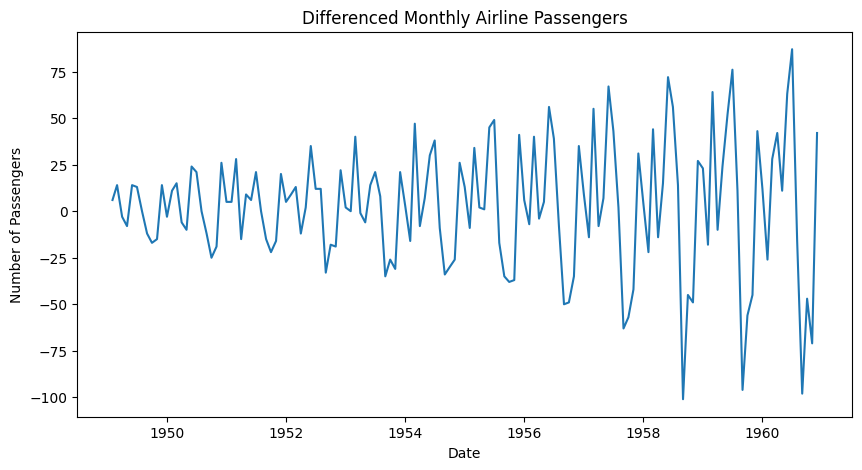

In [19]:
# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(airline_data_diff)
plt.title('Differenced Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.show()



Statistical Interpretation

Trend Removal:

The differencing process has effectively eliminated the upward trend observed in the original data. The series now fluctuates around zero, indicating a stable mean over time.

Reduced Non-Stationarity:

Compared to the original series, the differenced data shows no visible long-term increase or decrease, suggesting that the series is closer to stationarity. This observation aligns with the Augmented Dickey-Fuller (ADF) test result (p = 0.0542), which indicates borderline stationarity.

Persistent Seasonal Patterns:

Despite the removal of the trend, recurring peaks and troughs are still evident each year. This indicates that seasonal variation remains. To achieve full stationarity, additional seasonal differencing (e.g., using a lag of 12) may be necessary.

Variance Stability:

The scale of fluctuations appears relatively consistent over time, suggesting that the variance has stabilized. This is a positive indicator for ARIMA-type modeling.

Business / Practical Interpretation

After differencing, the data now reflects month-to-month changes in passenger numbers rather than absolute values.

Positive spikes indicate months with significant growth in passenger traffic compared to the previous month.
Negative spikes suggest declines or slowdowns in passenger numbers.
This transformed view is useful for identifying short-term demand shifts, seasonal dips, or periods of rapid growth that may correspond to specific events or seasonal trends.
The differenced data is now suitable for forecasting models such as ARIMA or SARIMA, which require stationarity.


Conclusion

The differenced series no longer exhibits a clear upward trend and now fluctuates around a stable mean, indicating that trend-based non-stationarity has been removed. However, the presence of seasonal patterns suggests that further seasonal differencing or seasonal modeling is needed to achieve full stationarity for accurate forecasting.

In [20]:
# Fit the ARMA(1, 1) model
model = ARIMA(airline_data_diff, order=(1, 0, 1))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -694.061
Date:                Tue, 28 Oct 2025   AIC                           1396.122
Time:                        04:23:47   BIC                           1407.973
Sample:                    02-01-1949   HQIC                          1400.937
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4507      3.441      0.712      0.476      -4.293       9.195
ar.L1         -0.4767      0.128     -3.735      0.000      -0.727      -0.227
ma.L1          0.8645      0.080     10.743      0.0

| Test                              | Statistic | p-value                                                                       | Interpretation                                                                                                                                                            |
| --------------------------------- | --------- | ----------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Ljung-Box Q(1)**                | 0.22      | 0.64                                                                          | The residuals show **no significant autocorrelation**, meaning the model explains the data’s time dependence well.                                                        |
| **Jarque-Bera (JB)**              | 2.17      | 0.34                                                                          | Residuals are **approximately normally distributed**, which is desirable.                                                                                                 |
| **Heteroskedasticity (H)**        | 7.01      | 0.00                                                                          | Indicates **some variance inconsistency** (heteroskedasticity), meaning the model’s residual variance changes over time — possibly due to seasonality not fully captured. |
| **Skew = -0.21, Kurtosis = 3.43** | —         | The residuals are slightly left-skewed but close to normal (Kurtosis near 3). |                                                                                                                                                                           |


Model Fit & Interpretation

The significant AR(1) and MA(1) terms suggest the series has short-term dependencies:
→ The AR term shows that the current passenger number depends negatively on the previous month.
→ The MA term captures short-term shocks or irregular fluctuations effectively.

Since the data was not differenced (d=0), the model assumes the series is stationary or nearly so — but earlier ADF tests indicated mild non-stationarity, meaning differencing or a seasonal component might improve the model.

Business Interpretation

Passenger numbers show short-term corrections after random fluctuations — if one month overshoots or undershoots the expected value, the next month tends to adjust.

The negative AR(1) effect suggests alternating patterns (a rise followed by a slight fall), possibly linked to monthly travel cycles.

However, residual variance inconsistency (heteroskedasticity) implies that seasonal effects are not fully modeled, so a SARIMA model (with seasonal terms, e.g., ARIMA(1,1,1)(1,1,1,12)) would likely yield a better fit.

Conclusion

The ARIMA(1,0,1) model provides a statistically sound baseline with significant AR and MA effects and uncorrelated, nearly normal residuals.
However, because of slight heteroskedasticity and known seasonality in the data, a seasonal ARIMA (SARIMA) model would likely provide a more accurate and stable forecast of airline passenger trends.

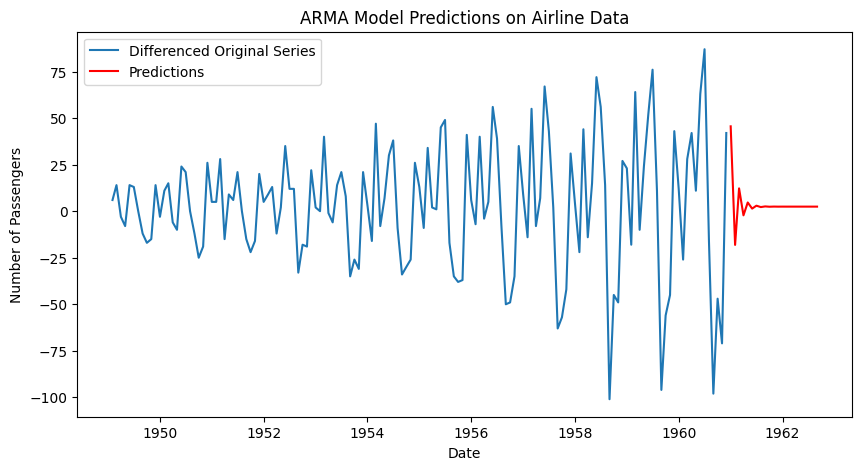

In [21]:
# Make predictions
start = len(airline_data_diff)
end = start + 20
predictions = model_fit.predict(start=start, end=end)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(airline_data_diff, label='Differenced Original Series')
plt.plot(predictions, label='Predictions', color='red')
plt.legend()
plt.title('ARMA Model Predictions on Airline Data')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.show()

Statistical

•	Blue Line (Differenced Original Series):

Represents the actual differenced values of monthly passenger data. It fluctuates around zero, indicating month-to-month changes (increases or decreases) in passenger numbers.

•	Red Line (Predictions):

Represents the forecasted values from the ARMA (Autoregressive Moving Average) model, based on past differenced observations.

•	Model Fit and Forecast:

The forecast (red line) initially follows the direction of the actual data but quickly stabilizes around zero.

This suggests that the ARMA model captures short-term dynamics but fails to reflect long-term seasonal or trending behavior.

•	Stationarity of Predictions:

Since the model is trained on differenced data, the predictions hover around a constant mean (approximately zero), confirming that the ARMA model assumes the series is stationary.

Business / Practical Interpretation

•	The model forecasts month-to-month changes rather than absolute passenger numbers.

•	The flat future predictions (around zero) imply that the model expects no significant growth or decline, indicating stabilization after short-term adjustments.

•	However, real-world airline demand typically exhibits strong seasonality and trends. Therefore, the ARMA model does not adequately capture seasonal peaks and troughs.

Model Assessment

•	The ARMA model offers a reasonable short-term forecast for changes in passenger numbers.

•	However, due to the absence of seasonal components, it is unsuitable for long-term forecasting.

•	A SARIMA or SARIMAX model (which includes seasonal lags) would be more appropriate, as the airline dataset clearly shows annual periodic patterns.

 Conclusion

The ARMA model effectively captures short-term fluctuations in the differenced airline passenger data but fails to represent long-term seasonal trends.
The flat forecast indicates that the model expects the differenced series to stabilize, confirming its stationarity.
For realistic forecasting of passenger volumes, a seasonal ARIMA (SARIMA) model should be used to incorporate yearly seasonality.

